#Step 1: Selection
##Goal: Identify and select the dataset that will be used for analysis.


#Step 2: Preprocessing
##Goal: Clean and preprocess the dataset to prepare it for analysis.

In [1]:
import pandas as pd

# Load the dataset
data = pd.read_csv('/content/kaggle/heart.csv')

# Display the first few rows of the dataset
print(data.head())

# Check for missing values and data types
print(data.info())

# Basic statistics of numerical columns
print(data.describe())


   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5 

#Step 3: Transformation
##Goal: Transform the data to a suitable format for analysis, including normalization, feature encoding, and feature selection.

In [2]:
from sklearn.preprocessing import StandardScaler

# Normalize the numerical features
scaler = StandardScaler()
numerical_features = data.select_dtypes(include=['int64', 'float64']).columns
data[numerical_features] = scaler.fit_transform(data[numerical_features])

# Encode categorical variables if needed (e.g., for 'sex' and 'cp')
data = pd.get_dummies(data, columns=['sex', 'cp'], drop_first=True)

# Display transformed dataset
print(data.head())


        age  trestbps      chol       fbs   restecg   thalach     exang  \
0  0.952197  0.763956 -0.256334  2.394438 -1.005832  0.015443 -0.696631   
1 -1.915313 -0.092738  0.072199 -0.417635  0.898962  1.633471 -0.696631   
2 -1.474158 -0.092738 -0.816773 -0.417635 -1.005832  0.977514 -0.696631   
3  0.180175 -0.663867 -0.198357 -0.417635  0.898962  1.239897 -0.696631   
4  0.290464 -0.663867  2.082050 -0.417635  0.898962  0.583939  1.435481   

    oldpeak     slope        ca      thal    target  sex_0.6810052246069987  \
0  1.087338 -2.274579 -0.714429 -2.148873  0.914529                    True   
1  2.122573 -2.274579 -0.714429 -0.512922  0.914529                    True   
2  0.310912  0.976352 -0.714429 -0.512922  0.914529                   False   
3 -0.206705  0.976352 -0.714429 -0.512922  0.914529                    True   
4 -0.379244  0.976352 -0.714429 -0.512922  0.914529                   False   

   cp_0.03203121617799389  cp_1.0025770663712101  cp_1.9731229165644262  


#Step 4: Data Mining
##Goal: Apply data mining techniques such as classification, clustering, or association rule mining to extract patterns from the data.

In [5]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score


# Define features and target variable
X = data.drop('target', axis=1)  # Assuming 'target' is the label column
y = data['target']

# !!! The issue is likely here. Ensure 'target' is not scaled/normalized. !!!
# If 'target' is scaled, revert it back to original 0/1 values if necessary.
# For example, if you previously applied StandardScaler to 'target':
# y = (y > 0).astype(int) # This converts scaled values back to 0/1

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest Classifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print(classification_report(y_test, y_pred))
print(f'Accuracy: {accuracy_score(y_test, y_pred)}')

              precision    recall  f1-score   support

           0       0.83      0.83      0.83        29
           1       0.84      0.84      0.84        32

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61

Accuracy: 0.8360655737704918


#Step 5: Evaluation
##Goal: Evaluate the effectiveness of the data mining techniques applied and the insights gained.

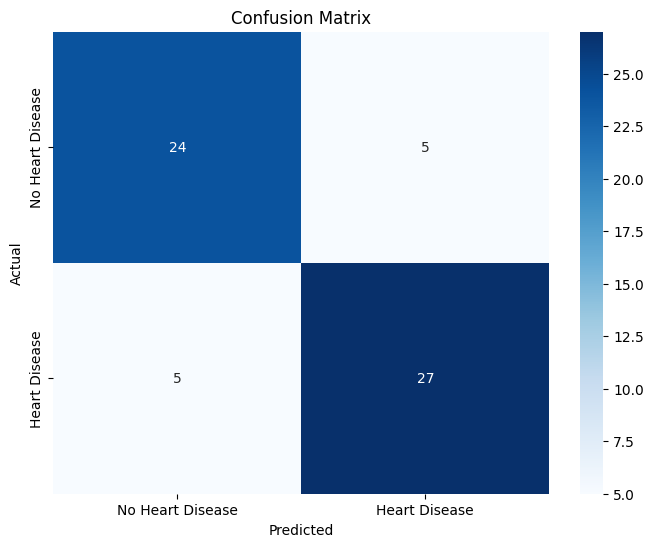

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Heart Disease', 'Heart Disease'], yticklabels=['No Heart Disease', 'Heart Disease'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()
